#  Notebook 06 — Visualization

## Goal
Create comprehensive, professional visualizations to communicate insights:
- Machine and failure distributions
- Sensor reading patterns
- Model performance metrics
- Feature importance
- Risk analysis
- Business impact (cost savings)

All visualizations will be saved to `reports/figures/` for use in presentations and reports.

In [2]:
import os
os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import warnings

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [12,6]
plt.rcParams['font.size'] = 11

print(os.getcwd())
print("All Libraries Imported Successfully")

/Users/jayeshranghera/Documents/Projects/predictive-maintenance-analysis
All Libraries Imported Successfully


In [4]:
df = pd.read_csv('data/processed/cleaned_data.csv')
print("data Loaded ")
print(f'Dataset Shape {df.shape}')

data Loaded 
Dataset Shape (10000, 12)


## 2.Data Distribution Visulaization 

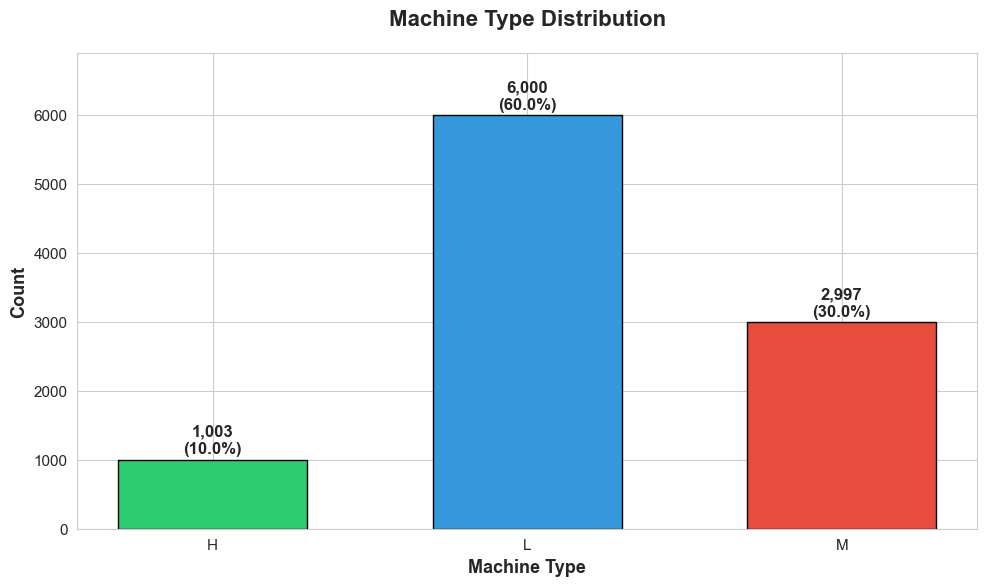

Saved: 01_machine_type_distribution.png


In [7]:
# Chart 1: Machine Type Distribution
fig, ax = plt.subplots(figsize=(10, 6))

type_counts = df['machine_type'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Machine Type Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Machine Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_ylim(0, type_counts.max() * 1.15)

plt.tight_layout()
plt.savefig('reports/figures/01_machine_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 01_machine_type_distribution.png')

## 3.Failure ANalysis Visulalization

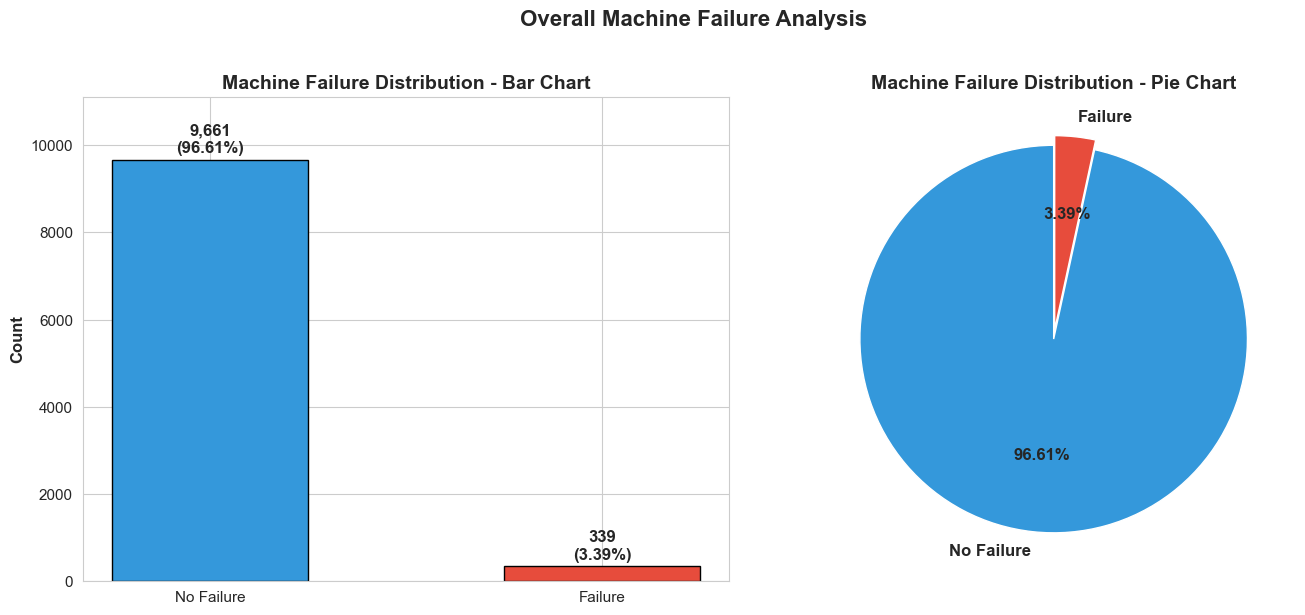

Saved: 02_failure_distribution.png


In [8]:
# Chart 2: Overall Failure Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

failure_counts = df['machine_failure'].value_counts().sort_index()
labels = ['No Failure', 'Failure']
colors_fail = ['#3498db', '#e74c3c']

# Bar chart
bars = axes[0].bar(labels, failure_counts.values, color=colors_fail, edgecolor='black', width=0.5)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 100,
                f'{int(height):,}\n({height/len(df)*100:.2f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Machine Failure Distribution - Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, failure_counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    failure_counts.values, 
    labels=labels,
    autopct='%1.2f%%',
    colors=colors_fail,
    startangle=90,
    explode=(0, 0.05),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

axes[1].set_title('Machine Failure Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.suptitle('Overall Machine Failure Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/02_failure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 02_failure_distribution.png')

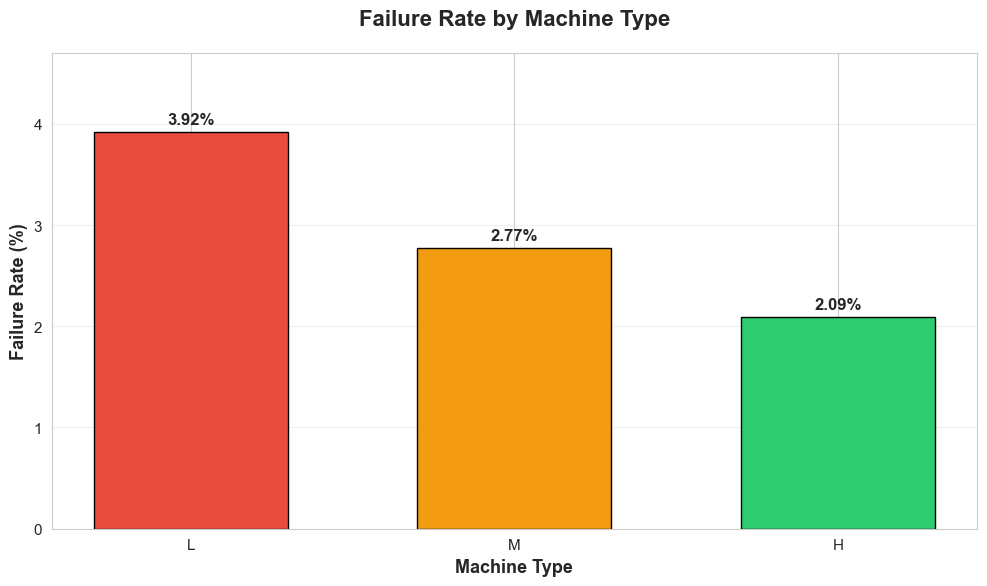

Saved: 03_failure_rate_by_type.png


In [11]:
# Chart 3: Failure Rate by Machine Type
fig, ax = plt.subplots(figsize=(10, 6))

failure_by_type = df.groupby('machine_type').agg({
    'machine_failure': ['count', 'sum', 'mean']
})
failure_by_type.columns = ['Total', 'Failures', 'Rate']
failure_by_type['Rate_Pct'] = failure_by_type['Rate'] * 100
failure_by_type = failure_by_type.sort_values('Rate_Pct', ascending=False)

bars = ax.bar(failure_by_type.index, failure_by_type['Rate_Pct'], 
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Failure Rate by Machine Type', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Machine Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Failure Rate (%)', fontsize=13, fontweight='bold')
ax.set_ylim(0, failure_by_type['Rate_Pct'].max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/03_failure_rate_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 03_failure_rate_by_type.png')

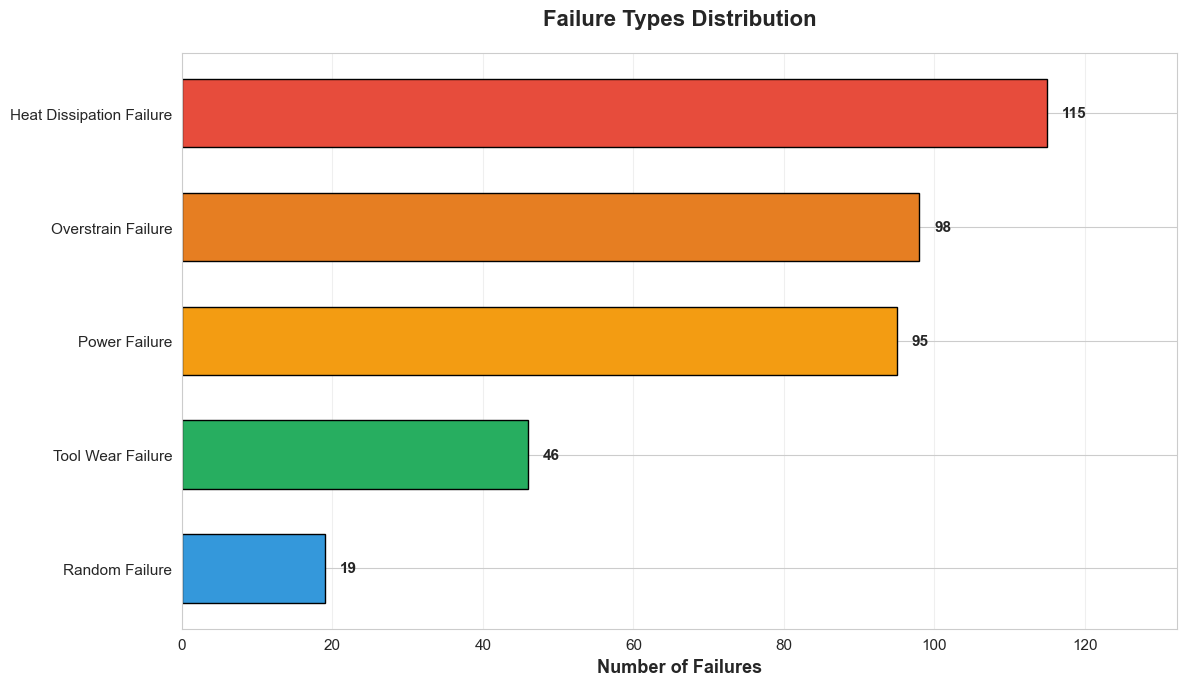

Saved: 04_failure_types_distribution.png


In [12]:
# Chart 4: Failure Types Distribution
fig, ax = plt.subplots(figsize=(12, 7))

failure_types = {
    'Tool Wear Failure': df['tool_wear_failure'].sum(),
    'Heat Dissipation Failure': df['heat_dissipation_failure'].sum(),
    'Power Failure': df['power_failure'].sum(),
    'Overstrain Failure': df['overstrain_failure'].sum(),
    'Random Failure': df['random_failure'].sum()
}

failure_df = pd.DataFrame(list(failure_types.items()), columns=['Type', 'Count'])
failure_df = failure_df.sort_values('Count', ascending=True)

colors_types = ['#3498db', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.barh(failure_df['Type'], failure_df['Count'], 
               color=colors_types, edgecolor='black', height=0.6)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_title('Failure Types Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Failures', fontsize=13, fontweight='bold')
ax.set_xlim(0, failure_df['Count'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/04_failure_types_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 04_failure_types_distribution.png')

## 4. Sensor Reading Comparison

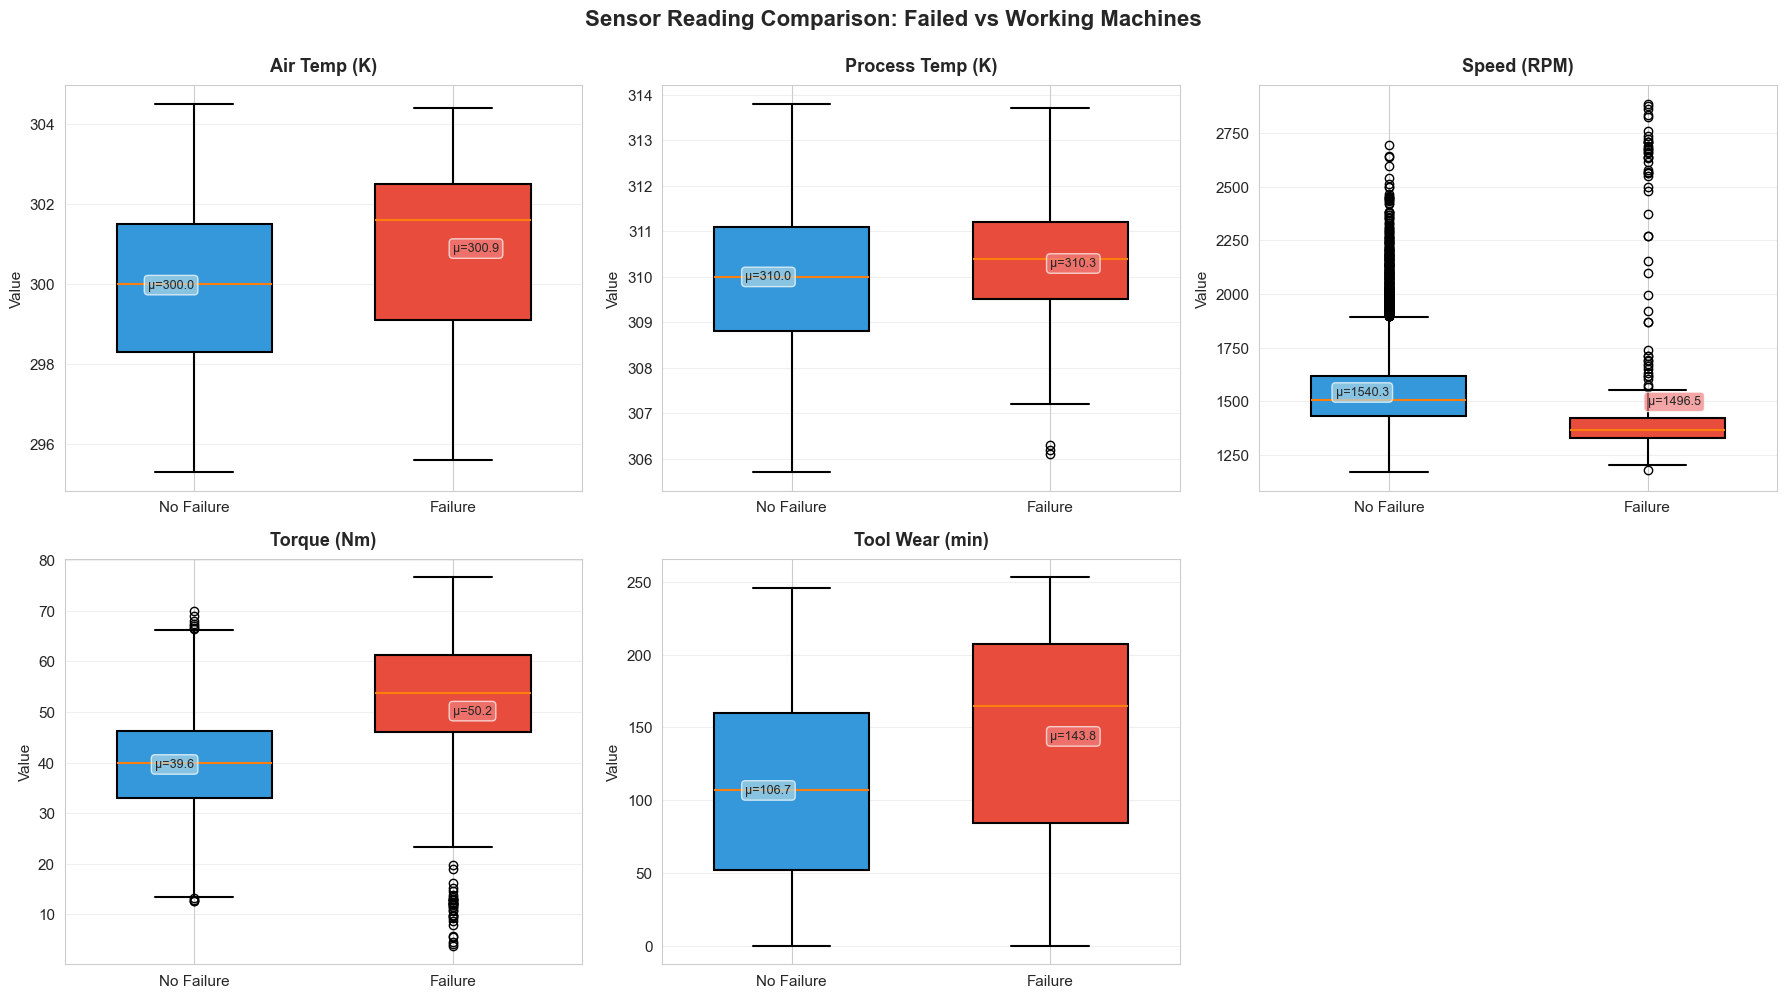

Saved: 05_sensor_comparison.png


In [13]:
# Chart 5: Sensor Readings - Failed vs Working Machines
failed = df[df['machine_failure'] == 1]
working = df[df['machine_failure'] == 0]

sensor_features = ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
feature_labels = ['Air Temp (K)', 'Process Temp (K)', 'Speed (RPM)', 'Torque (Nm)', 'Tool Wear (min)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (feature, label) in enumerate(zip(sensor_features, feature_labels)):
    ax = axes[idx]
    
    # Box plots
    bp = ax.boxplot(
        [working[feature], failed[feature]],
        labels=['No Failure', 'Failure'],
        patch_artist=True,
        widths=0.6
    )
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], linewidth=1.5)
    
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Value', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean values as text
    mean_working = working[feature].mean()
    mean_failed = failed[feature].mean()
    ax.text(1, mean_working, f'μ={mean_working:.1f}', 
            ha='right', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    ax.text(2, mean_failed, f'μ={mean_failed:.1f}', 
            ha='left', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Sensor Reading Comparison: Failed vs Working Machines', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('reports/figures/05_sensor_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 05_sensor_comparison.png')

## 5.Correlation Analysis

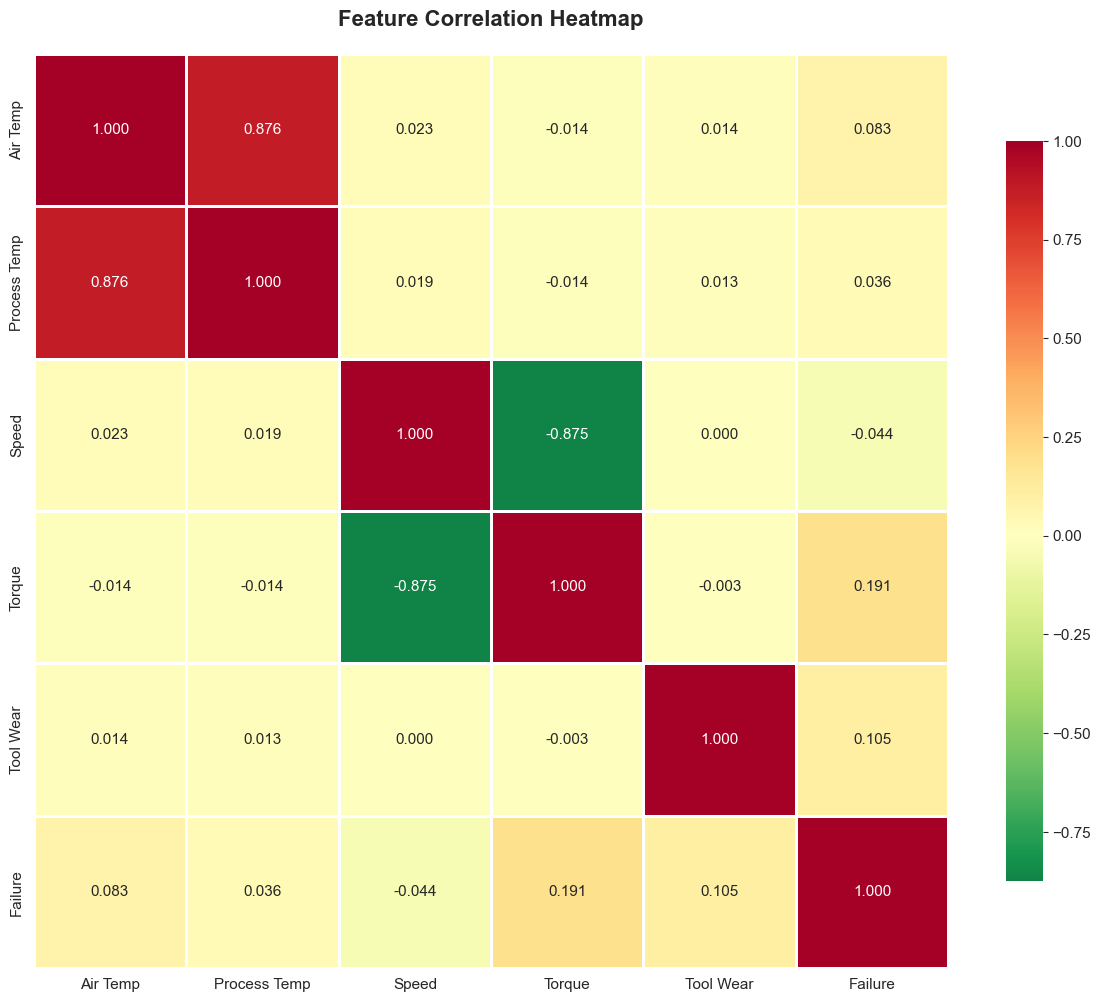

Saved: 06_correlation_heatmap.png


In [14]:
# Chart 6: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Select numerical features
numerical_features = [
    'air_temp_k', 
    'process_temp_k', 
    'rotational_speed_rpm', 
    'torque_nm', 
    'tool_wear_min',
    'machine_failure'
]

# Readable labels
labels = [
    'Air Temp',
    'Process Temp',
    'Speed',
    'Torque',
    'Tool Wear',
    'Failure'
]

corr_matrix = df[numerical_features].corr()

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('reports/figures/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 06_correlation_heatmap.png')

## 6.ML Model Performance

In [15]:
# Load model and make predictions (for confusion matrix)
from sklearn.model_selection import train_test_split

# Load ML-ready data
df_ml = pd.read_csv('data/processed/ml_ready_data.csv')
X = df_ml.drop('machine_failure', axis=1)
y = df_ml['machine_failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load trained model
with open('models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Model loaded and predictions made!')

Model loaded and predictions made!


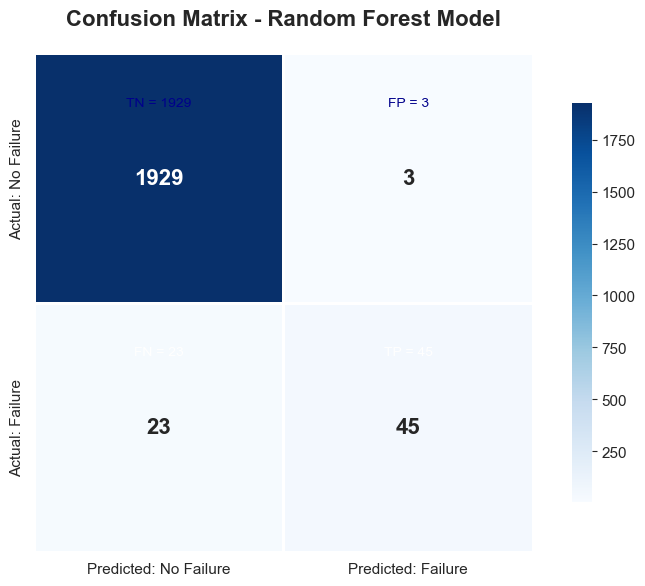

Saved: 07_confusion_matrix.png


In [17]:
# Chart 7: Confusion Matrix
fig, ax = plt.subplots(figsize=(8,6))

# Create confusion matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    linewidths=2,
    cbar_kws={"shrink": 0.8},
    xticklabels=['Predicted: No Failure', 'Predicted: Failure'],
    yticklabels=['Actual: No Failure', 'Actual: Failure'],
    ax=ax,
    annot_kws={'size': 16, 'weight': 'bold'}
)

ax.set_title('Confusion Matrix - Random Forest Model', fontsize=16, fontweight='bold', pad=20)

# Add text annotations for each cell
ax.text(0.5, 0.2, f'TN = {cm[0][0]}', ha='center', va='center', fontsize=10, color='darkblue')
ax.text(1.5, 0.2, f'FP = {cm[0][1]}', ha='center', va='center', fontsize=10, color='darkblue')
ax.text(0.5, 1.2, f'FN = {cm[1][0]}', ha='center', va='center', fontsize=10, color='white')
ax.text(1.5, 1.2, f'TP = {cm[1][1]}', ha='center', va='center', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('reports/figures/07_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 07_confusion_matrix.png')

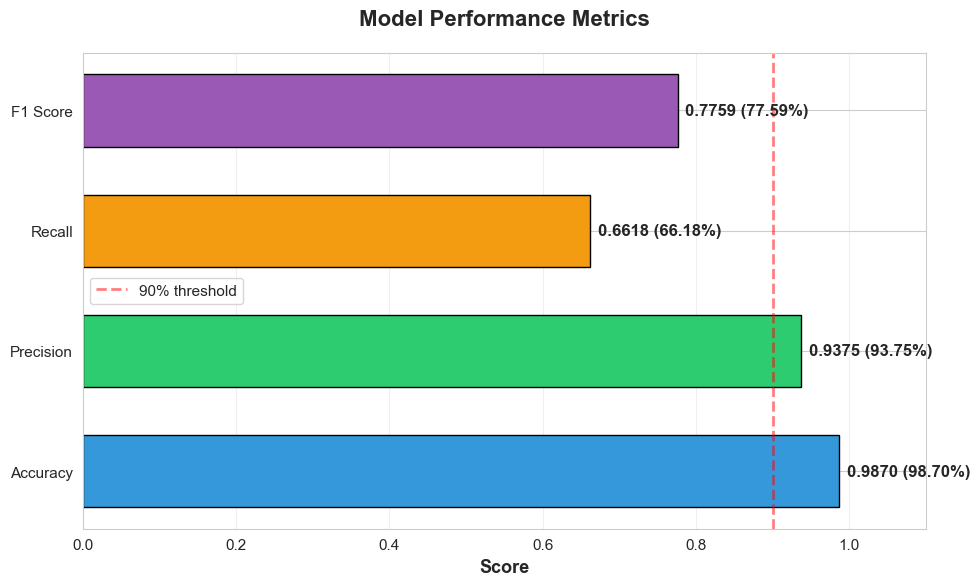

Saved: 08_model_metrics.png


In [18]:
# Chart 8: Model Performance Metrics
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']

bars = ax.barh(metrics, values, color=colors_metrics, edgecolor='black', height=0.6)

# Add value labels
for bar, value in zip(bars, values):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2.,
            f'{value:.4f} ({value*100:.2f}%)',
            ha='left', va='center', fontsize=12, fontweight='bold')

ax.set_title('Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Score', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.axvline(x=0.9, color='red', linestyle='--', linewidth=2, alpha=0.5, label='90% threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/08_model_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 08_model_metrics.png')

## 7.Feature Importance

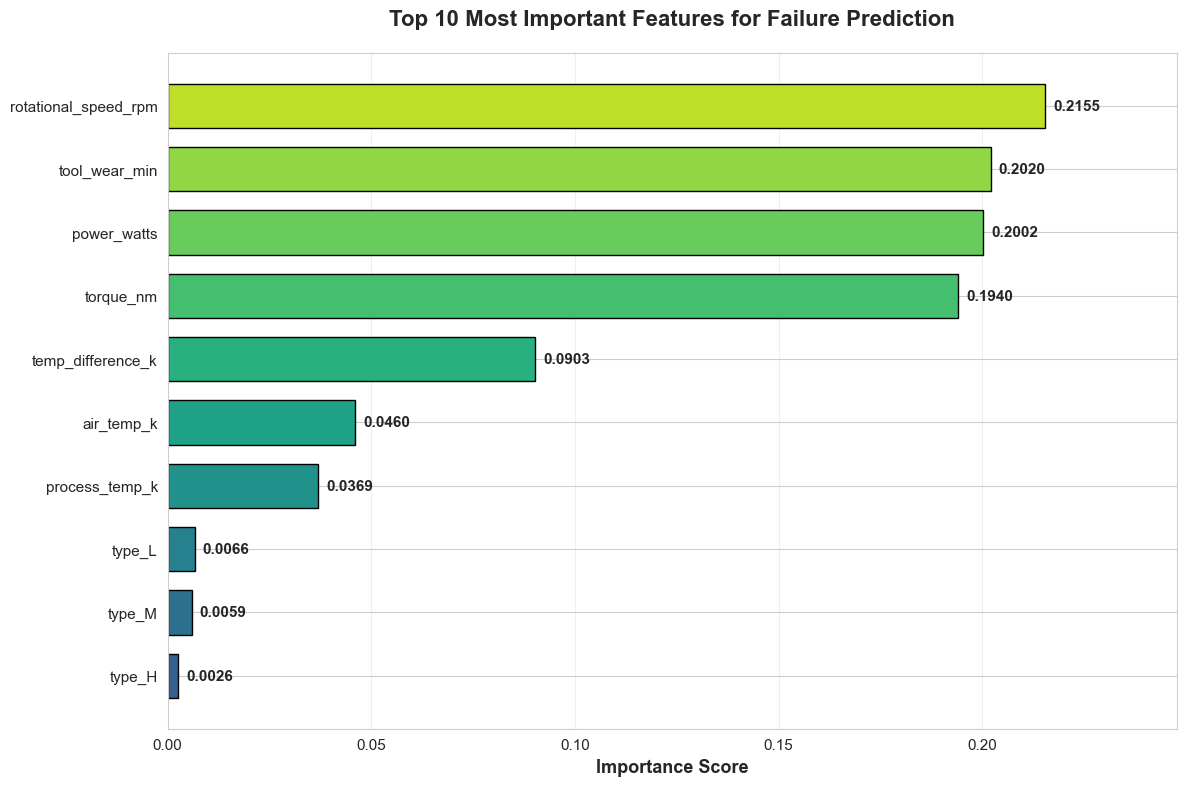

Saved: 09_feature_importance.png


In [19]:
# Chart 9: Feature Importance
fig, ax = plt.subplots(figsize=(12, 8))

# Load feature names
with open('models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})
importance_df = importance_df.sort_values('Importance', ascending=True).tail(10)  # Top 10

# Create color gradient
colors_importance = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))

bars = ax.barh(importance_df['Feature'], importance_df['Importance'], 
               color=colors_importance, edgecolor='black', height=0.7)

# Add value labels
for bar, value in zip(bars, importance_df['Importance']):
    ax.text(value + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{value:.4f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_title('Top 10 Most Important Features for Failure Prediction', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=13, fontweight='bold')
ax.set_xlim(0, importance_df['Importance'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/09_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 09_feature_importance.png')

## 8.Risk Analysis Visulizations

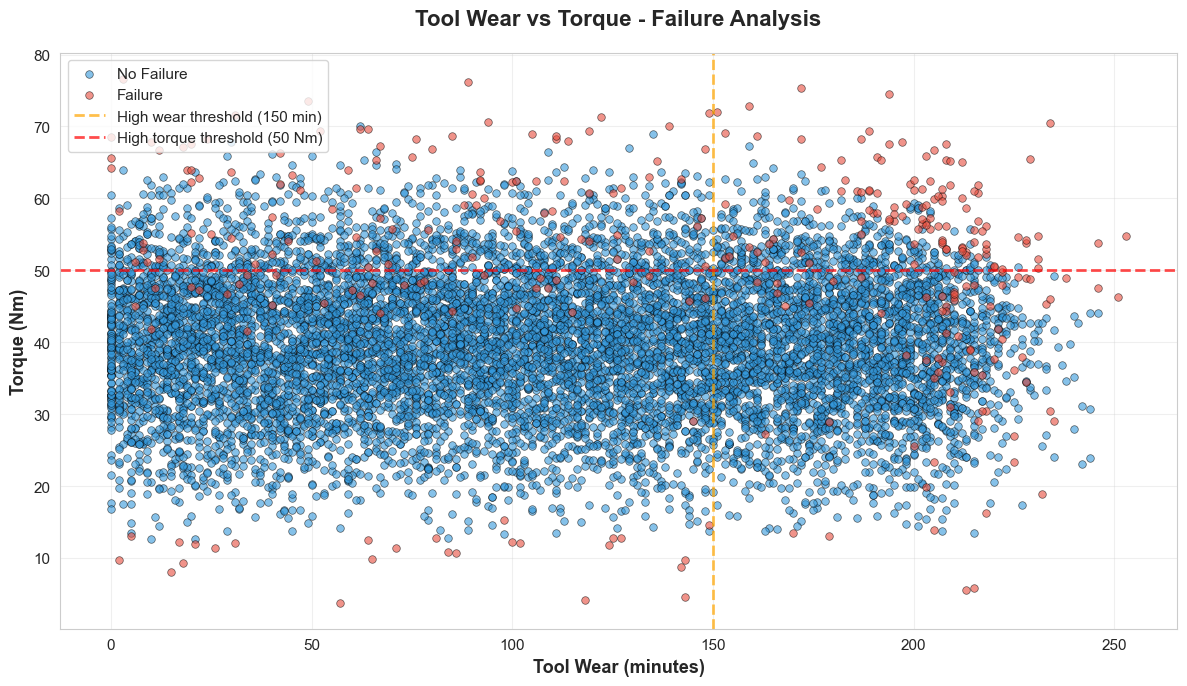

Saved: 10_tool_wear_vs_torque.png


In [20]:
# Chart 10: Tool Wear vs Machine Failure
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot
for failure_status, color, label in [(0, '#3498db', 'No Failure'), (1, '#e74c3c', 'Failure')]:
    data = df[df['machine_failure'] == failure_status]
    ax.scatter(
        data['tool_wear_min'],
        data['torque_nm'],
        c=color,
        label=label,
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )

# Add risk threshold lines
ax.axvline(x=150, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='High wear threshold (150 min)')
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='High torque threshold (50 Nm)')

ax.set_title('Tool Wear vs Torque - Failure Analysis', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tool Wear (minutes)', fontsize=13, fontweight='bold')
ax.set_ylabel('Torque (Nm)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/10_tool_wear_vs_torque.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 10_tool_wear_vs_torque.png')


## 9. Business Impact Visualizations

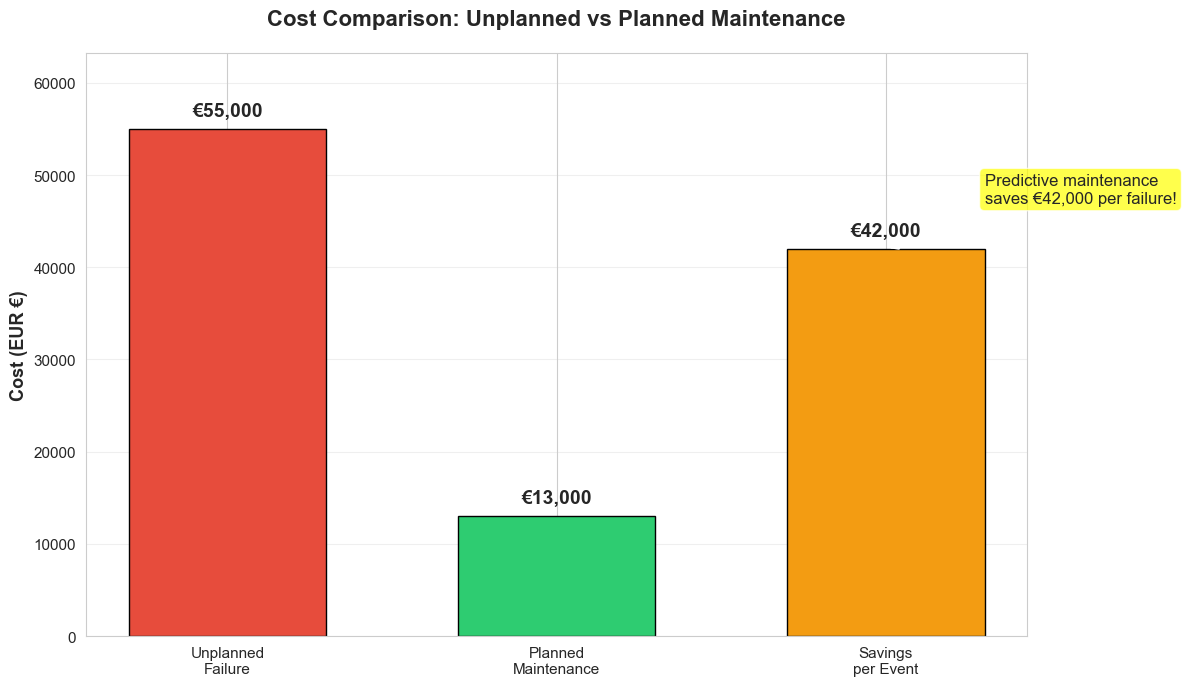

Saved: 11_cost_savings.png


In [21]:
# Chart 11: Cost Savings Visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Cost data
categories = ['Unplanned\nFailure', 'Planned\nMaintenance', 'Savings\nper Event']
costs = [55000, 13000, 42000]  # EUR values from NB 05
colors_cost = ['#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(categories, costs, color=colors_cost, edgecolor='black', width=0.6)

# Add value labels
for bar, cost in zip(bars, costs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f'€{cost:,.0f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_title('Cost Comparison: Unplanned vs Planned Maintenance', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Cost (EUR €)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(costs) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Add annotation
ax.annotate(
    'Predictive maintenance\nsaves €42,000 per failure!',
    xy=(2, costs[2]),
    xytext=(2.3, costs[2] + 5000),
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
    arrowprops=dict(arrowstyle='->', lw=2)
)

plt.tight_layout()
plt.savefig('reports/figures/11_cost_savings.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 11_cost_savings.png')

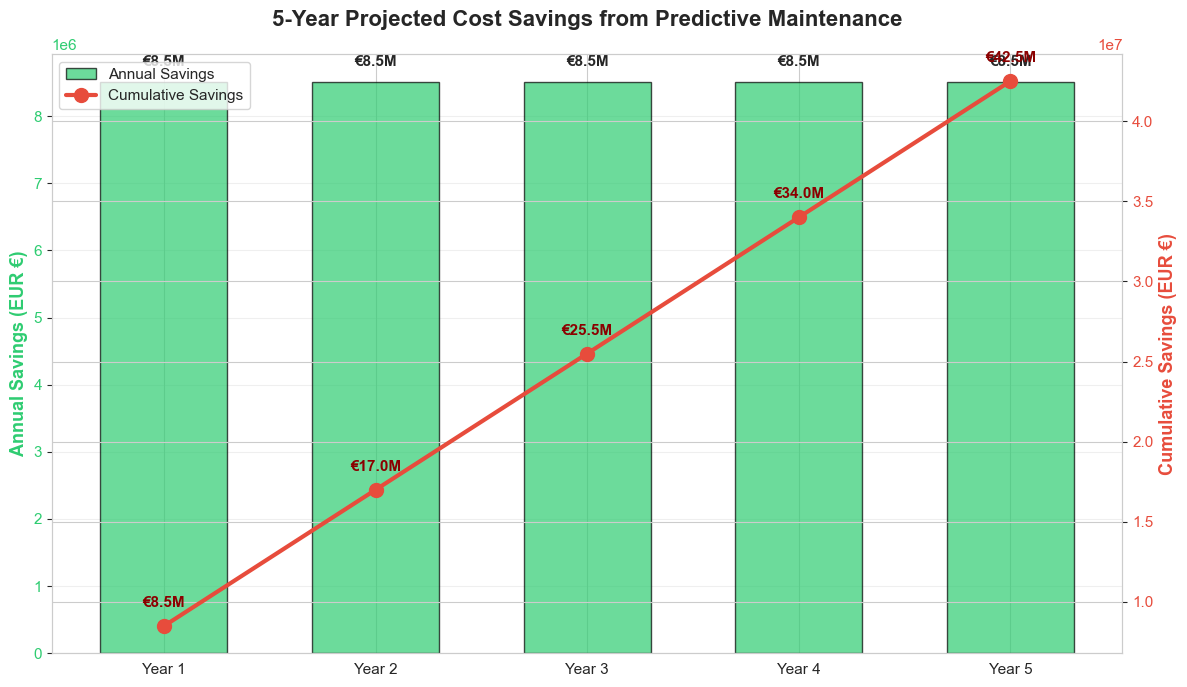

Saved: 12_annual_savings_projection.png


In [22]:
# Chart 12: Annual Savings Projection
fig, ax = plt.subplots(figsize=(12, 7))

# Annual projection
years = ['Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5']
savings = [8500000, 8500000, 8500000, 8500000, 8500000]  # EUR from NB 05
cumulative = np.cumsum(savings)

# Bar chart for annual savings
bars = ax.bar(years, savings, color='#2ecc71', alpha=0.7, edgecolor='black', width=0.6, label='Annual Savings')

# Line chart for cumulative
ax2 = ax.twinx()
line = ax2.plot(years, cumulative, color='#e74c3c', marker='o', linewidth=3, 
                markersize=10, label='Cumulative Savings')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 200000,
            f'€{height/1000000:.1f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add value labels on line
for i, (x, y) in enumerate(zip(years, cumulative)):
    ax2.text(i, y + 1000000, f'€{y/1000000:.1f}M',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='darkred')

ax.set_title('5-Year Projected Cost Savings from Predictive Maintenance', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Annual Savings (EUR €)', fontsize=13, fontweight='bold', color='#2ecc71')
ax2.set_ylabel('Cumulative Savings (EUR €)', fontsize=13, fontweight='bold', color='#e74c3c')
ax.tick_params(axis='y', labelcolor='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/12_annual_savings_projection.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: 12_annual_savings_projection.png')

# Visualization Summary

---

## All Visualizations Created and Saved

**Location:** `reports/figures/`

---

##  Charts Created

###  Data Distribution
1. Machine type distribution  
2. Overall failure distribution (bar + pie)  
3. Failure rate by machine type  
4. Failure types distribution  

---

###  Sensor Analysis
5. Sensor reading comparison (failed vs working)  
6. Feature correlation heatmap  
7. Tool wear vs torque scatter  

---

###  Model Performance
8. Confusion matrix  
9. Model performance metrics  
10. Feature importance (Top 10)  

---

###  Business Impact
11. Cost comparison (unplanned vs planned)  
12. Annual savings projection (5 years)  

---

##  Chart Quality Standards

-  High resolution (300 DPI)  
-  Professional styling  
-  Clear labels and titles  
-  Ready for presentations and reports  
-  Publication quality  

---